# Advection Equation

Here we solve the advection equation $u_t + a u_x=0$ using a step function $u(x, t = 0) = 1$ for x ∈ [4, 6] and $u(x, t = 0) = 0$ in the rest of the domain.

We use a domain $x\in [0,10]$ with periodic boundary conditions and use the Lax - Wendroff scheme.

nx= 101
dx= 0.1
dt= 0.020000000000000004
Number of iterations= 999.9999999999998


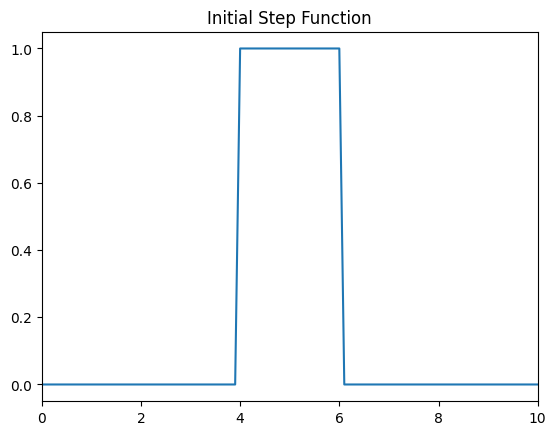

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#define the speed a
a=1.0

# Define the domain
L = 10.0     # Domain length
nx = 101   # Number of grid points
dx = L/(nx-1)   # Grid spacing -> in this case the error goes as dx^2, reducing the number of points nx will give larger oscillations
#using nx = 50 for example gives a pretty evident result
x = np.linspace(0, L, nx)

##print(x,'\n',dx) #just a check

# Define the time step and the final time
cf = 0.2 # -> error also goes as 1-cf^2: larger cf weaker oscillations
#i tried using cf = 0.3 but there wasn't a very evident change, probably it's just due to the fact
#that the scaling of dx^2 dominates over it

dt = cf*dx/a   # Time step
t_final = 20.0

print('nx=',nx)
print('dx=',dx)
print('dt=',dt)
print('Number of iterations=',t_final/dt)


# Define the initial condition
x1, x2 = 4.0, 6.0
u_initial = np.zeros(nx)
i = 0
for xi in x:
    if (xi>= x1) and (xi <= x2): u_initial[i] = 1
    i+= 1

plt.plot(x, u_initial)
plt.title('Initial Step Function')
plt.xlim(0, 10)
plt.show()

# Initialize the solution array
u_current = u_initial.copy()

#we create arrays where we will store the time and the l2norm
l2norm=[]
l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

time=[]
time.append(0.0)

In [2]:
import os
##create directory where to save images
print(os.getcwd())

#os.makedirs('./img_SF_LW')

os.listdir('./')

C:\Users\lm101\Desktop\Uni\numerical_relativity_2025\Advection


['.ipynb_checkpoints',
 'Advection_Equation.ipynb',
 'Advection_Equation_Leapfrog.ipynb',
 'Advection_Equation_LF.ipynb',
 'Advection_Equation_LW.ipynb',
 'AE_Step_LF.ipynb',
 'AE_Step_LW.ipynb',
 'images',
 'images_Leapfrog',
 'images_LF',
 'images_LW',
 'img_SF_LF',
 'img_SF_LW',
 'l2norm_FTCS.dat',
 'l2norm_LAX.dat',
 'l2norm_LAXWENDROFF.dat',
 'l2norm_LEAPFROG.dat',
 'movie.mp4',
 'movie_Leapfrog.mp4',
 'movie_LF.mp4',
 'movie_LW.mp4',
 'movie_SF_LF.mp4',
 'movie_SF_LW.mp4',
 'README.md']

In [3]:
# Initilize time and iteration counter
t = 0.0
i = 0

#save the initial conditions
plt.plot(x, u_current)
plt.title('Time='+str(round(t,2)))
plt.ylim(-0.5,1.3)
plt.savefig('./img_SF_LW/fig_'+str(i).zfill(5)+'.png', dpi=200)
plt.close()

#solve the advection equation
while t < t_final:
    # Compute the new solution using the Lax Wendroff method
    # Note: np.roll(u_current, -1) is equivalent to u(j+1) and
    #       np.roll(u_current,  1) is equivalent to u(j-1)
    # using np.roll is equivalent to use periodic boundary conditions
    u_next = ( u_current - a*dt/(2*dx)*(np.roll(u_current, -1) - np.roll(u_current, 1)) 
            + a**2*(dt**2)/(2 * dx**2)*(np.roll(u_current, -1) - 2*u_current + np.roll(u_current, 1)) )
    
    # Update the solution
    u_current = u_next.copy()
    
    
    #advance the time 
    t += dt
    i += 1
    
    #compute the l2 norm and add the time to the time vector
    l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
    time.append(t)
    
    #plot the current result and save in an image every 10 iterations
    if (i%10==0):
        plt.plot(x, u_current)
        plt.title('Time='+str(round(t,2)))
        plt.ylim(-0.5,1.3) #plotting the negative axis to look at the effects of the dispersive term
        plt.savefig('./img_SF_LW/fig_'+str(i).zfill(5)+'.png', dpi=200)
        plt.close()


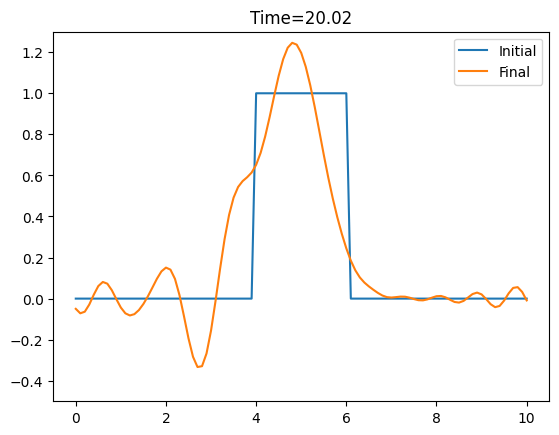

In [4]:
# Plot the final solution
plt.plot(x, u_initial, label='Initial')
plt.plot(x, u_current, label='Final')
plt.title('Time='+str(round(t,2)))
plt.ylim(-0.5,1.3)
plt.legend()
plt.show()

In [5]:
# set the directory where your images are stored
directory = "./img_SF_LW/"

# get the list of image files in the directory
files = os.listdir(directory)

print(files, '\n')

# sort the files in alphanumeric order
files=sorted(files)

#print(files)




['fig_00000.png', 'fig_00010.png', 'fig_00020.png', 'fig_00030.png', 'fig_00040.png', 'fig_00050.png', 'fig_00060.png', 'fig_00070.png', 'fig_00080.png', 'fig_00090.png', 'fig_00100.png', 'fig_00110.png', 'fig_00120.png', 'fig_00130.png', 'fig_00140.png', 'fig_00150.png', 'fig_00160.png', 'fig_00170.png', 'fig_00180.png', 'fig_00190.png', 'fig_00200.png', 'fig_00210.png', 'fig_00220.png', 'fig_00230.png', 'fig_00240.png', 'fig_00250.png', 'fig_00260.png', 'fig_00270.png', 'fig_00280.png', 'fig_00290.png', 'fig_00300.png', 'fig_00310.png', 'fig_00320.png', 'fig_00330.png', 'fig_00340.png', 'fig_00350.png', 'fig_00360.png', 'fig_00370.png', 'fig_00380.png', 'fig_00390.png', 'fig_00400.png', 'fig_00410.png', 'fig_00420.png', 'fig_00430.png', 'fig_00440.png', 'fig_00450.png', 'fig_00460.png', 'fig_00470.png', 'fig_00480.png', 'fig_00490.png', 'fig_00500.png', 'fig_00510.png', 'fig_00520.png', 'fig_00530.png', 'fig_00540.png', 'fig_00550.png', 'fig_00560.png', 'fig_00570.png', 'fig_00580.pn

In [6]:
from moviepy import ImageSequenceClip

clip = ImageSequenceClip('./img_SF_LW/', fps = 7)
clip.write_videofile('movie_SF_LW.mp4')
clip.close()

MoviePy - Building video movie_SF_LW.mp4.
MoviePy - Writing video movie_SF_LW.mp4



MoviePy - Done !
MoviePy - video ready movie_SF_LW.mp4


In [7]:
# don't worry about the code in this cell, it is just to let you 
# display the movies you generated above in Jupyter notebook
from IPython.display import HTML

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="./movie_SF_LW.mp4" type="video/mp4">
</video></div>""")

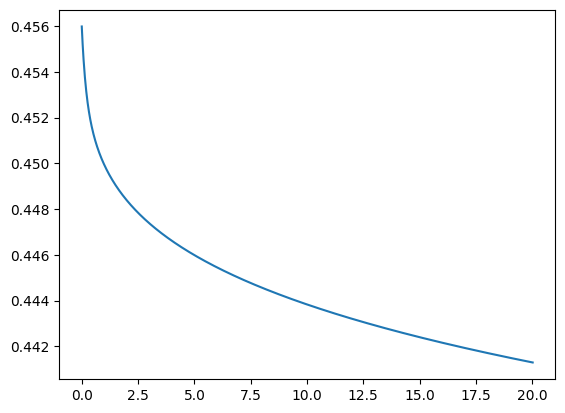

In [8]:
plt.plot(time,l2norm)
plt.show()

## Comments
Increasing the resolution (i.e. increasing the number of points to 801) will increase the frequency of oscillations and will never completely cancel them out, but the overall shape of the step function is better conserved in time.